# 02 - Feature Engineering

Goal: build the early-window feature table (day-1/day-2 cutoff only) for
each of the 607 events, join it against the `severity_class` labels from
`01_data_ingestion.ipynb`, and evaluate GBM (XGBoost) and EBM (InterpretML)
baselines.

**The primary reported result is the binary escalation target** (Step 9):
contained (severity 0) vs. escalates (1+2+3) -- the operationally
meaningful mobilize-or-not call, where the models clearly beat the majority
baseline. The 4-class quartile-tier results (Steps 5-8) are kept as
secondary: adjacent-tier separation is near-arbitrary at the bin
boundaries, and those numbers mostly measure that.

All evaluation is leave-one-year-out via
`flashpoint.evaluation.leave_one_year_out` -- year-based splits, never
random (2019 is a known outlier year).

Everything here reads ONLY from the early cutoff window -- reaching into
later days would leak the label, since severity_class is derived from the
full trajectory.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
from flashpoint.db import get_connection
from flashpoint.data_access import BUFFER_DAYS

DB_PATH = Path("../data/flashpoint.duckdb")
CUTOFF_DAY = 2  # use the fire's first 2 ACTUAL days as the "early" window
# The stored sequences open with BUFFER_DAYS (4) pre-ignition padding days,
# so the early window is indices [BUFFER_DAYS, BUFFER_DAYS + CUTOFF_DAY) --
# slicing from index 0 would mostly measure pre-ignition conditions.

con = get_connection(DB_PATH)
events_df = con.execute("SELECT * FROM events").df()
outcomes_df = con.execute("SELECT * FROM event_outcomes").df()
print(f"{len(events_df)} events, {len(outcomes_df)} outcomes")

607 events, 607 outcomes


## Step 1: Filter out events too short for the cutoff

An event needs at least `BUFFER_DAYS + CUTOFF_DAY` stored days for the
post-buffer early window to exist at all -- the first `BUFFER_DAYS` indices
are pre-ignition padding, not fire days.

In [2]:
min_days = BUFFER_DAYS + CUTOFF_DAY
too_short = events_df[events_df['n_days'] < min_days]
print(f"{len(too_short)} events have fewer than {min_days} days "
      f"({BUFFER_DAYS} buffer + {CUTOFF_DAY} fire days) -- these get dropped")

usable_events = events_df[events_df['n_days'] >= min_days].copy()
print(f"{len(usable_events)} usable events remain")

0 events have fewer than 6 days (4 buffer + 2 fire days) -- these get dropped
607 usable events remain


## Step 2: Compute early-window features per event

In [3]:
import pandas as pd
from tqdm import tqdm
from flashpoint.data_access import HDF5Event, read_event_window
from flashpoint.features import early_window_stats

feature_rows = []
for row in tqdm(usable_events.itertuples(), total=len(usable_events)):
    event = HDF5Event(
        event_id=row.event_id, year=row.year, hdf5_path=Path(row.hdf5_path),
        n_days=row.n_days, img_dates=[], lnglat=(row.centroid_lon, row.centroid_lat),
    )
    # skip the pre-ignition buffer: the fire's real day 1 is at index BUFFER_DAYS
    early_stack = read_event_window(event, BUFFER_DAYS, BUFFER_DAYS + CUTOFF_DAY)
    stats = early_window_stats(early_stack)
    stats["event_id"] = row.event_id
    feature_rows.append(stats)

features_df = pd.DataFrame(feature_rows)
features_df.head()


  0%|          | 0/607 [00:00<?, ?it/s]


  1%|          | 5/607 [00:00<00:14, 42.62it/s]


  2%|▏         | 11/607 [00:00<00:11, 50.05it/s]


  3%|▎         | 17/607 [00:00<00:12, 47.09it/s]


  4%|▍         | 23/607 [00:00<00:11, 49.51it/s]

...


 97%|█████████▋| 591/607 [00:08<00:00, 69.26it/s]


 99%|█████████▊| 599/607 [00:08<00:00, 69.46it/s]


100%|██████████| 607/607 [00:09<00:00, 69.29it/s]


100%|██████████| 607/607 [00:09<00:00, 66.74it/s]

,fire_extent_ha,wind_speed_mean,wind_speed_max,wind_direction_sin_mean,wind_direction_cos_mean,max_temp_max,min_temp_min,humidity_min,pdsi_mean,erc_mean,...,slope_max,aspect_sin_mean,aspect_cos_mean,elevation_mean,ndvi_mean,evi2_mean,viirs_m11_mean,viirs_i1_mean,viirs_i2_mean,event_id
0,0.0000,1.754568,2.4,0.058103,0.082854,296.799988,278.500000,0.00555,-1.769814,30.021702,...,30.107311,-0.068001,0.105162,152.971664,3342.108398,1791.945435,2857.488037,3579.583984,4163.215820,fire_21458798
1,928.1250,2.694789,6.7,0.449271,-0.655066,296.600006,267.700012,0.00185,-2.831900,67.874252,...,56.541397,-0.041087,0.116153,1771.304688,2732.257324,1449.604736,2096.450684,1406.174927,2421.752197,fire_21458801
2,0.0000,2.025493,2.7,-0.707315,0.591090,294.899994,276.299988,0.00401,-1.902884,29.257885,...,30.107311,0.029064,0.109750,173.749542,3661.309814,1812.693970,3913.282227,4563.650879,4995.578125,fire_21458806
3,0.0000,1.460857,3.6,0.186333,-0.515001,297.200012,274.600006,0.00104,-1.563438,64.117889,...,34.734871,-0.238990,0.112281,221.434708,3025.122070,1745.019775,4179.355469,5360.729004,5772.980469,fire_21458836
4,182.8125,5.984562,12.0,0.002291,-0.831940,293.000000,257.500000,0.00117,-2.827684,58.026360,...,35.807865,0.042856,0.057710,1875.309570,3618.774414,1700.524292,1547.601196,1436.669312,2630.859131,fire_21458848


In [4]:
# NaN check on the new topography/vegetation features -- VIIRS/NDVI/EVI2 can
# be missing for a whole window (clouds). XGBoost handles NaN natively so no
# imputation, but the counts should be looked at, not assumed.
NEW_COLS = [
    "slope_mean", "slope_max", "aspect_sin_mean", "aspect_cos_mean", "elevation_mean",
    "ndvi_mean", "evi2_mean", "viirs_m11_mean", "viirs_i1_mean", "viirs_i2_mean",
]
print(features_df[NEW_COLS].isna().sum())

slope_mean          0
slope_max           0
aspect_sin_mean     0
aspect_cos_mean     0
elevation_mean      0
ndvi_mean          41
evi2_mean          41
viirs_m11_mean      4
viirs_i1_mean       4
viirs_i2_mean       4
dtype: int64


## Step 3: Write early_features to DuckDB, then join with labels

In [5]:
from flashpoint.db import SCHEMA_SQL

# The schema gained the topography/vegetation columns -- CREATE TABLE IF NOT
# EXISTS won't widen an existing table, so drop and recreate. early_features
# is fully derived data rebuilt right here, so nothing is lost.
con.execute("DROP TABLE IF EXISTS early_features")
con.execute(SCHEMA_SQL)

insert_rows = [
    (
        r["event_id"], CUTOFF_DAY, r["fire_extent_ha"], r["wind_speed_mean"],
        r["wind_speed_max"], r["wind_direction_sin_mean"], r["wind_direction_cos_mean"],
        r["max_temp_max"], r["min_temp_min"], r["humidity_min"], r["pdsi_mean"], r["erc_mean"],
        r["slope_mean"], r["slope_max"], r["aspect_sin_mean"], r["aspect_cos_mean"],
        r["elevation_mean"], r["ndvi_mean"], r["evi2_mean"],
        r["viirs_m11_mean"], r["viirs_i1_mean"], r["viirs_i2_mean"],
    )
    for r in feature_rows
]
con.executemany(
    "INSERT OR REPLACE INTO early_features VALUES "
    "(?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)",
    insert_rows,
)
con.commit()

train_df = con.execute("""
    SELECT e.year, f.*, o.severity_class
    FROM early_features f
    JOIN events e ON e.event_id = f.event_id
    JOIN event_outcomes o ON o.event_id = f.event_id
""").df()
print(train_df.shape)
train_df.head()

(607, 24)


,year,event_id,cutoff_day,fire_extent_ha,wind_speed_mean,wind_speed_max,wind_direction_sin_mean,wind_direction_cos_mean,max_temp_max,min_temp_min,...,slope_max,aspect_sin_mean,aspect_cos_mean,elevation_mean,ndvi_mean,evi2_mean,viirs_m11_mean,viirs_i1_mean,viirs_i2_mean,severity_class
0,2018,fire_21458798,2,0.0000,1.754568,2.4,0.058103,0.082854,296.799988,278.500000,...,30.107311,-0.068001,0.105162,152.971664,3342.108398,1791.945435,2857.488037,3579.583984,4163.215820,0
1,2018,fire_21458801,2,928.1250,2.694789,6.7,0.449271,-0.655066,296.600006,267.700012,...,56.541397,-0.041087,0.116153,1771.304688,2732.257324,1449.604736,2096.450684,1406.174927,2421.752197,0
2,2018,fire_21458806,2,0.0000,2.025493,2.7,-0.707315,0.591090,294.899994,276.299988,...,30.107311,0.029064,0.109750,173.749542,3661.309814,1812.693970,3913.282227,4563.650879,4995.578125,1
3,2018,fire_21458836,2,0.0000,1.460857,3.6,0.186333,-0.515001,297.200012,274.600006,...,34.734871,-0.238990,0.112281,221.434708,3025.122070,1745.019775,4179.355469,5360.729004,5772.980469,0
4,2018,fire_21458848,2,182.8125,5.984562,12.0,0.002291,-0.831940,293.000000,257.500000,...,35.807865,0.042856,0.057710,1875.309570,3618.774414,1700.524292,1547.601196,1436.669312,2630.859131,0


## Step 4: Year-based train/test split (not random)

Per the paper's own recommendation: yearly distributions vary a lot (2019
is a known outlier -- fewer, smaller fires), so a random shuffle risks an
unrepresentative split. Hold out one full year as the test set instead --
e.g. train on 2018/2020/2021, test on 2019, or run this across a few
held-out years to sanity check stability before committing to one split.

In [6]:
BASE_FEATURE_COLS = [
    "fire_extent_ha", "wind_speed_mean", "wind_speed_max",
    "wind_direction_sin_mean", "wind_direction_cos_mean",
    "max_temp_max", "min_temp_min", "humidity_min", "pdsi_mean", "erc_mean",
]
TOPO_COLS = [
    "slope_mean", "slope_max", "aspect_sin_mean", "aspect_cos_mean", "elevation_mean",
]
VEG_COLS = [
    "ndvi_mean", "evi2_mean", "viirs_m11_mean", "viirs_i1_mean", "viirs_i2_mean",
]
FEATURE_COLS = BASE_FEATURE_COLS + TOPO_COLS + VEG_COLS

TEST_YEAR = 2019  # known outlier year in this dataset -- a good stress test

train = train_df[train_df["year"] != TEST_YEAR]
test = train_df[train_df["year"] == TEST_YEAR]

X_train, y_train = train[FEATURE_COLS], train["severity_class"]
X_test, y_test = test[FEATURE_COLS], test["severity_class"]

print(f"Train: {len(train)} events, Test: {len(test)} events")
print("Train class balance:\n", y_train.value_counts().sort_index())
print("Test class balance:\n", y_test.value_counts().sort_index())

Train: 533 events, Test: 74 events
Train class balance:
 severity_class
0    125
1    123
2    138
3    147
Name: count, dtype: int64
Test class balance:
 severity_class
0    30
1    26
2    14
3     4
Name: count, dtype: int64


## Step 5: XGBoost baseline

In [7]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softmax", num_class=4, eval_metric="mlogloss",
    random_state=0,
)
xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.63      0.58        30
           1       0.40      0.08      0.13        26
           2       0.33      0.50      0.40        14
           3       0.08      0.25      0.12         4

    accuracy                           0.39        74
   macro avg       0.34      0.37      0.31        74
weighted avg       0.42      0.39      0.36        74

[[19  2  5  4]
 [12  2  8  4]
 [ 4  0  7  3]
 [ 1  1  1  1]]


## Step 6: EBM baseline (fully interpretable, glass-box)

Trained on the exact same features and split, so its accuracy and its
native explanations are directly comparable to XGBoost + SHAP.

In [8]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_clf = ExplainableBoostingClassifier(random_state=0)
ebm_clf.fit(X_train, y_train)

y_pred_ebm = ebm_clf.predict(X_test)
print(classification_report(y_test, y_pred_ebm))

/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


              precision    recall  f1-score   support

           0       0.56      0.60      0.58        30
           1       0.50      0.19      0.28        26
           2       0.36      0.57      0.44        14
           3       0.20      0.50      0.29         4

    accuracy                           0.45        74
   macro avg       0.41      0.47      0.40        74
weighted avg       0.48      0.45      0.43        74



In [9]:
from flashpoint.evaluation import leave_one_year_out


def make_xgb_4class():
    return xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        objective="multi:softmax", num_class=4, eval_metric="mlogloss", random_state=0,
    )


results_df = leave_one_year_out(train_df, FEATURE_COLS, "severity_class", make_xgb_4class)
print(results_df.to_string(index=False))
print(f"\nMean accuracy: {results_df['accuracy'].mean():.3f}")
print(f"Mean macro F1: {results_df['macro_f1'].mean():.3f}")

 test_year  n_test  accuracy  macro_f1
      2018     176  0.494318  0.489901
      2019      74  0.391892  0.307447
      2020     201  0.412935  0.405037
      2021     156  0.435897  0.438256

Mean accuracy: 0.434
Mean macro F1: 0.410


## Step 7: Ablation -- do topography / vegetation features actually help?

Leave-one-year-out XGBoost (same params as above) on four feature sets:
base 10 only, base + topography, base + vegetation, and everything combined.
The "base (10)" row should reproduce the LOYO numbers from the previous cell
as a cross-check.

In [10]:
ablation = {
    "base (10)": BASE_FEATURE_COLS,
    "base + topo": BASE_FEATURE_COLS + TOPO_COLS,
    "base + veg": BASE_FEATURE_COLS + VEG_COLS,
    "base + topo + veg": FEATURE_COLS,
}

ablation_rows = []
for name, cols in ablation.items():
    res = leave_one_year_out(train_df, cols, "severity_class", make_xgb_4class)
    ablation_rows.append({
        "feature_set": name,
        "n_features": len(cols),
        "mean_accuracy": res["accuracy"].mean(),
        "mean_macro_f1": res["macro_f1"].mean(),
    })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))

      feature_set  n_features  mean_accuracy  mean_macro_f1
        base (10)          10       0.414392       0.401642
      base + topo          15       0.463109       0.442844
       base + veg          15       0.446569       0.422091
base + topo + veg          20       0.433761       0.410160


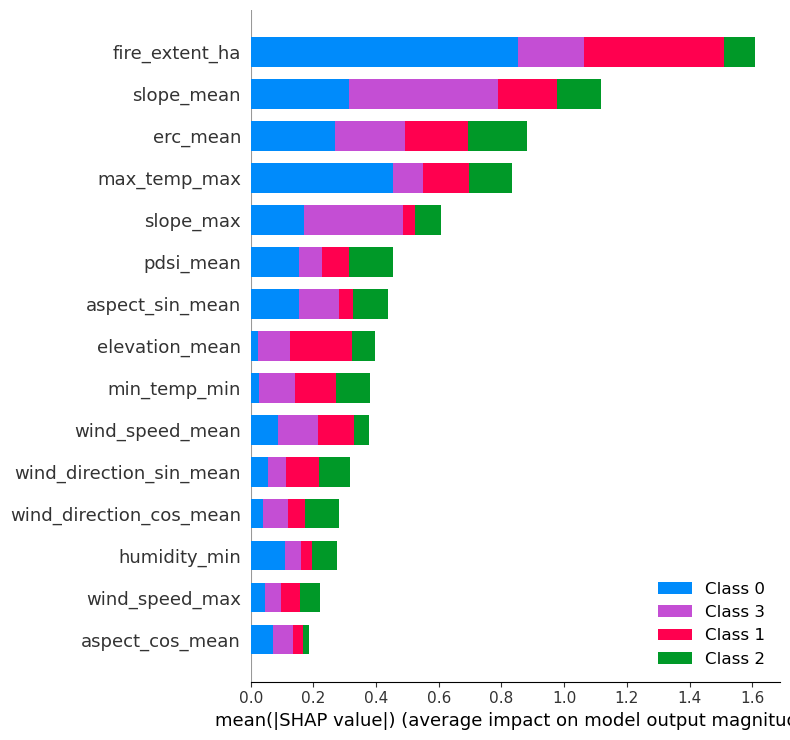

In [11]:
import shap

# SHAP on the ablation's best feature set (base + topo) -- vegetation
# features excluded since they slightly hurt LOYO performance
SHAP_COLS = BASE_FEATURE_COLS + TOPO_COLS

xgb_full = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softmax", num_class=4, eval_metric="mlogloss", random_state=0,
)
xgb_full.fit(train_df[SHAP_COLS], train_df["severity_class"])

explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(train_df[SHAP_COLS])

shap.summary_plot(shap_values, train_df[SHAP_COLS], plot_type="bar")

## Step 8: EBM on the best feature set -- LOYO eval + native importances

Same 15 features (base + topo) and same leave-one-year-out setup as the
XGBoost model above. `interactions=0` keeps the model mains-only -- the
earlier warning noted multiclass EBMs can't visualize pairs anyway, and it
makes `term_names_` line up 1:1 with the feature list, so the native
`term_importances()` ranking is directly comparable to the SHAP plot.

 test_year  n_test  accuracy  macro_f1
      2018     176  0.500000  0.491746
      2019      74  0.391892  0.327604
      2020     201  0.383085  0.384202
      2021     156  0.461538  0.464848

EBM LOYO mean accuracy: 0.434
EBM LOYO mean macro F1: 0.417



EBM term importances (mean |score|):
fire_extent_ha             0.445263
slope_mean                 0.276814
erc_mean                   0.204790
max_temp_max               0.129681
wind_speed_mean            0.101547
slope_max                  0.087768
aspect_sin_mean            0.087744
min_temp_min               0.070627
pdsi_mean                  0.069603
elevation_mean             0.068627
wind_direction_cos_mean    0.045696
humidity_min               0.040069
wind_direction_sin_mean    0.037692
aspect_cos_mean            0.032781
wind_speed_max             0.032635


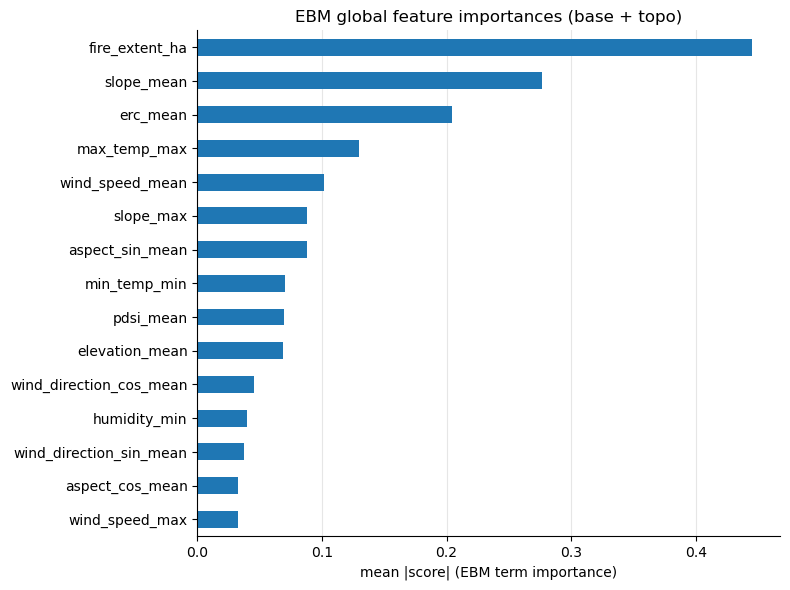

In [12]:
import matplotlib.pyplot as plt


def make_ebm():
    return ExplainableBoostingClassifier(interactions=0, random_state=0)


# leave-one-year-out eval, same folds and feature set as the XGBoost SHAP model
ebm_results_df = leave_one_year_out(train_df, SHAP_COLS, "severity_class", make_ebm)
print(ebm_results_df.to_string(index=False))
print(f"\nEBM LOYO mean accuracy: {ebm_results_df['accuracy'].mean():.3f}")
print(f"EBM LOYO mean macro F1: {ebm_results_df['macro_f1'].mean():.3f}")

# native global importances from an EBM trained on all events -- mirrors the
# SHAP cell, where xgb_full is also fit on the full dataset for explanation
ebm_full = make_ebm()
ebm_full.fit(train_df[SHAP_COLS], train_df["severity_class"])

ebm_importances = pd.Series(
    ebm_full.term_importances(), index=ebm_full.term_names_
).sort_values(ascending=False)
print("\nEBM term importances (mean |score|):")
print(ebm_importances.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ebm_importances.iloc[::-1].plot.barh(ax=ax, color="#1f77b4")
ax.set_xlabel("mean |score| (EBM term importance)")
ax.set_title("EBM global feature importances (base + topo)")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="0.9")
ax.set_axisbelow(True)
plt.tight_layout()

## Step 9: PRIMARY RESULT -- binary escalation: contained (0) vs. escalates (1+2+3)

Collapse the quartile tiers to the operationally meaningful call: does this
fire stay in the bottom quartile of peak extent, or not. Same base+topo
features and LOYO folds as Steps 7-8. This is the project's primary
reported result; the 4-class rows appear below it for reference.

Two metric notes:

- Since tiers are quartiles, the binary target is ~25/75 imbalanced, so a
  majority-class predictor already gets ~0.75 accuracy (vs. ~0.25 chance on
  4 classes). Raw binary accuracy is NOT comparable to 4-class accuracy --
  the majority baseline row and macro-F1 are the honest reference points.
- `escalates_recall` (recall on the escalates class) is reported separately
  because the operational cost is asymmetric: missing a fire that goes on
  to escalate is worse than a false alarm. Note the majority baseline
  trivially scores 1.0 here by always predicting "escalates" -- it buys
  that recall with zero ability to stand down, which is why recall is read
  alongside macro-F1, not instead of it.

In [13]:
from sklearn.dummy import DummyClassifier

train_df["escalates"] = (train_df["severity_class"] > 0).astype(int)
print("Binary class balance:")
print(train_df["escalates"].value_counts().sort_index().to_string())


def make_xgb_binary():
    return xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        objective="binary:logistic", eval_metric="logloss", random_state=0,
    )


binary_models = {
    "ebm (binary)": make_ebm,
    "xgb (binary)": make_xgb_binary,
    "majority (binary)": lambda: DummyClassifier(strategy="most_frequent"),
}

oof_preds = {}
summary_rows = []
for name, factory in binary_models.items():
    res, preds = leave_one_year_out(
        train_df, SHAP_COLS, "escalates", factory,
        positive_class=1, return_predictions=True,
    )
    oof_preds[name] = preds
    summary_rows.append({
        "model": name,
        "mean_accuracy": res["accuracy"].mean(),
        "mean_macro_f1": res["macro_f1"].mean(),
        "escalates_recall": res["positive_recall"].mean(),
    })

# secondary 4-class reference rows, pulled from the Step 7 ablation and
# Step 8 EBM results so this table self-updates if those cells change
# (escalates_recall doesn't apply to the 4-class target)
topo_row = ablation_df[ablation_df["feature_set"] == "base + topo"].iloc[0]
summary_rows.append({
    "model": "xgb (4-class)",
    "mean_accuracy": topo_row["mean_accuracy"],
    "mean_macro_f1": topo_row["mean_macro_f1"],
})
summary_rows.append({
    "model": "ebm (4-class)",
    "mean_accuracy": ebm_results_df["accuracy"].mean(),
    "mean_macro_f1": ebm_results_df["macro_f1"].mean(),
})

binary_summary_df = pd.DataFrame(summary_rows)
print("\nLOYO means, base+topo features (primary result first):")
print(binary_summary_df.to_string(index=False))

Binary class balance:
escalates
0    155
1    452



LOYO means, base+topo features (primary result first):
            model  mean_accuracy  mean_macro_f1  escalates_recall
     ebm (binary)       0.825802       0.753946          0.952816
     xgb (binary)       0.788116       0.718026          0.883536
majority (binary)       0.725180       0.419002          1.000000
    xgb (4-class)       0.463109       0.442844               NaN
    ebm (4-class)       0.434129       0.417100               NaN


In [14]:
# The LOYO folds are disjoint and cover every event exactly once, so the
# pooled out-of-fold predictions form ONE true confusion matrix over all
# 607 events -- not an average of per-fold matrices. Both classes' precision
# and recall are shown: contained-recall is the flip side the escalates
# recall number hides (how often do we correctly stand down, vs. false-alarm,
# on fires that genuinely stay contained).
for name in ("ebm (binary)", "xgb (binary)"):
    preds = oof_preds[name]
    print(f"===== {name}: pooled out-of-fold, all {len(preds)} events =====")
    print("confusion matrix (rows = true contained/escalates, cols = predicted):")
    print(confusion_matrix(preds["y_true"], preds["y_pred"]))
    print(classification_report(
        preds["y_true"], preds["y_pred"],
        target_names=["contained", "escalates"], digits=3,
    ))

===== ebm (binary): pooled out-of-fold, all 607 events =====
confusion matrix (rows = true contained/escalates, cols = predicted):
[[ 77  78]
 [ 18 434]]
              precision    recall  f1-score   support

   contained      0.811     0.497     0.616       155
   escalates      0.848     0.960     0.900       452

    accuracy                          0.842       607
   macro avg      0.829     0.728     0.758       607
weighted avg      0.838     0.842     0.828       607

===== xgb (binary): pooled out-of-fold, all 607 events =====
confusion matrix (rows = true contained/escalates, cols = predicted):
[[ 80  75]
 [ 43 409]]
              precision    recall  f1-score   support

   contained      0.650     0.516     0.576       155
   escalates      0.845     0.905     0.874       452

    accuracy                          0.806       607
   macro avg      0.748     0.710     0.725       607
weighted avg      0.795     0.806     0.798       607



## Step 10: EBM local explanations for individual out-of-fold calls

Four exemplar events -- a true positive, true negative, false positive
(false alarm), and false negative (missed escalation) -- each explained by
`explain_local()` on **its own fold model** (the EBM trained with that
event's year held out). That's the same model that made the out-of-fold
prediction, so the explanation describes a genuine out-of-sample decision,
not a hindsight refit. Exemplars are the most confident event in each cell
of the confusion matrix (max/min out-of-fold P(escalate)).

Scores are logit contributions toward "escalates": positive pushes toward
mobilize, negative toward stand down.

In [15]:
ebm_oof = oof_preds["ebm (binary)"].copy()

# refit the four fold models (deterministic: same data, same random_state as
# inside leave_one_year_out) and collect out-of-fold P(escalate) per event
fold_ebms = {}
p_escalate = pd.Series(index=train_df.index, dtype=float)
for test_year in sorted(train_df["year"].unique()):
    tr = train_df[train_df["year"] != test_year]
    te = train_df[train_df["year"] == test_year]
    m = make_ebm()
    m.fit(tr[SHAP_COLS], tr["escalates"])
    fold_ebms[test_year] = m
    p_escalate.loc[te.index] = m.predict_proba(te[SHAP_COLS])[:, 1]

# cross-check: the refits must reproduce the helper's out-of-fold predictions
assert ((p_escalate >= 0.5).astype(int) == ebm_oof["y_pred"]).all()
ebm_oof["p_escalate"] = p_escalate


def pick_exemplar(y_true, y_pred, highest_p):
    """Most confident event in one confusion-matrix cell, or None if empty."""
    cell = ebm_oof[(ebm_oof["y_true"] == y_true) & (ebm_oof["y_pred"] == y_pred)]
    if cell.empty:
        return None
    return cell["p_escalate"].idxmax() if highest_p else cell["p_escalate"].idxmin()


exemplars = {
    "TRUE POSITIVE (predicted escalate; did)": pick_exemplar(1, 1, True),
    "TRUE NEGATIVE (predicted contained; stayed contained)": pick_exemplar(0, 0, False),
    "FALSE POSITIVE (false alarm on a contained fire)": pick_exemplar(0, 1, True),
    "FALSE NEGATIVE (missed escalation)": pick_exemplar(1, 0, False),
}

peak_ha = con.execute(
    "SELECT event_id, max_area_ha FROM event_outcomes"
).df().set_index("event_id")["max_area_ha"]

for label, idx in exemplars.items():
    if idx is None:
        print(f"===== {label}: no such events =====\n")
        continue
    row = train_df.loc[idx]
    m = fold_ebms[row["year"]]
    exp = m.explain_local(train_df.loc[[idx], SHAP_COLS], train_df.loc[[idx], "escalates"])
    d = exp.data(0)
    contribs = sorted(zip(d["names"], d["scores"], d["values"]), key=lambda t: -abs(t[1]))
    print(f"===== {label} =====")
    print(f"{row['event_id']} ({row['year']}) -- peak extent {peak_ha[row['event_id']]:,.0f} ha, "
          f"severity tier {row['severity_class']}, out-of-fold P(escalate) = "
          f"{ebm_oof.loc[idx, 'p_escalate']:.3f}")
    print("top contributions (logit toward 'escalates'; negative = toward 'contained'):")
    for feat_name, score, value in contribs[:6]:
        print(f"  {feat_name:<26} {score:+7.3f}   (value {value:.4g})")
    print()

===== TRUE POSITIVE (predicted escalate; did) =====
fire_24461347 (2020) -- peak extent 46,589 ha, severity tier 3, out-of-fold P(escalate) = 0.998
top contributions (logit toward 'escalates'; negative = toward 'contained'):
  fire_extent_ha              +2.219   (value 4.659e+04)
  slope_mean                  +0.684   (value 13.38)
  erc_mean                    +0.507   (value 85.77)
  max_temp_max                +0.435   (value 310.4)
  wind_speed_mean             +0.361   (value 5.875)
  wind_speed_max              +0.224   (value 11.1)

===== TRUE NEGATIVE (predicted contained; stayed contained) =====
fire_24695758 (2020) -- peak extent 1,238 ha, severity tier 0, out-of-fold P(escalate) = 0.024
top contributions (logit toward 'escalates'; negative = toward 'contained'):
  max_temp_max                -2.284   (value 281.2)
  erc_mean                    -0.979   (value 19.72)
  fire_extent_ha              -0.736   (value 0)
  min_temp_min                -0.638   (value 256.6)
  wind_

## Step 11: Diagnostic -- do false alarms come from already-plateaued fires?

For every event, "growth headroom" = day-2 `fire_extent_ha` / eventual
`max_area_ha`. Near 1.0 = the fire was already at/near its peak by day 2
(the `fire_24332969` pattern -- no further growth to predict); near 0 = most
of its growth was still ahead.

Comparing the ratio between the EBM's false positives and true negatives
(the two "actually stayed contained" groups) tests whether the missing
trend signal explains the false alarms: if FPs concentrate near 1.0 while
TNs spread lower, a growth-rate feature (day-2 minus day-1 extent) is worth
building; if not, the false alarms come from something a trend feature
wouldn't fix. Diagnostic only -- report the numbers either way.

(Ratio is NaN where `max_area_ha` = 0 -- nothing was ever detected, so
"headroom" is undefined; those events are counted separately.)

In [16]:
import numpy as np

diag = ebm_oof.copy()
diag["event_id"] = train_df["event_id"]
diag["fire_extent_ha"] = train_df["fire_extent_ha"]
diag["max_area_ha"] = train_df["event_id"].map(peak_ha)
diag["headroom_ratio"] = np.where(
    diag["max_area_ha"] > 0,
    diag["fire_extent_ha"] / diag["max_area_ha"],
    np.nan,
)

groups = {
    "false positives (pred escalate, stayed contained)":
        diag[(diag["y_true"] == 0) & (diag["y_pred"] == 1)],
    "true negatives (pred contained, stayed contained)":
        diag[(diag["y_true"] == 0) & (diag["y_pred"] == 0)],
}

for name, g in groups.items():
    r = g["headroom_ratio"].dropna()
    n_zero_peak = int(g["headroom_ratio"].isna().sum())
    print(f"===== {name}: n={len(g)} =====")
    if n_zero_peak:
        print(f"  (excluding {n_zero_peak} events with max_area_ha = 0, ratio undefined)")
    print(f"  mean ratio:      {r.mean():.3f}")
    print(f"  median ratio:    {r.median():.3f}")
    print(f"  fraction > 0.9:  {(r > 0.9).mean():.3f}  ({(r > 0.9).sum()}/{len(r)})")
    print(f"  fraction < 0.5:  {(r < 0.5).mean():.3f}  ({(r < 0.5).sum()}/{len(r)})")
    print(f"  deciles (10/25/50/75/90%): "
          + " / ".join(f"{q:.2f}" for q in r.quantile([0.1, 0.25, 0.5, 0.75, 0.9])))
    print()

===== false positives (pred escalate, stayed contained): n=78 =====
  mean ratio:      0.305
  median ratio:    0.098
  fraction > 0.9:  0.167  (13/78)
  fraction < 0.5:  0.718  (56/78)
  deciles (10/25/50/75/90%): 0.00 / 0.00 / 0.10 / 0.55 / 1.00

===== true negatives (pred contained, stayed contained): n=77 =====
  mean ratio:      0.299
  median ratio:    0.000
  fraction > 0.9:  0.182  (14/77)
  fraction < 0.5:  0.701  (54/77)
  deciles (10/25/50/75/90%): 0.00 / 0.00 / 0.00 / 0.80 / 1.00



In [17]:
import sys, numpy
print(sys.executable)
print(numpy.__version__)

/Users/pmacias/opt/anaconda3/envs/flashpoint/bin/python
2.3.5


In [18]:
con.close()